In [1]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode


@tool
def shipment_lookup(order_id: str) -> str:
    """Return mock shipment status for an order."""
    db = {"8f2e4c": "shipped", "9a1b2c": "delivered"}
    return db.get(order_id, "unknown")

@tool
def cancel_order(order_id: str) -> str:
    """Cancel a pending order if it has not shipped yet."""
    return f"Order {order_id} cancellation request submitted."

tool_node = ToolNode([shipment_lookup, cancel_order])

d:\Ambilio\EXL-CampusHire\Week2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(tool_node._tools_by_name)

{'shipment_lookup': StructuredTool(name='shipment_lookup', description='Return mock shipment status for an order.', args_schema=<class 'langchain_core.utils.pydantic.shipment_lookup'>, func=<function shipment_lookup at 0x000001B089A96A20>), 'cancel_order': StructuredTool(name='cancel_order', description='Cancel a pending order if it has not shipped yet.', args_schema=<class 'langchain_core.utils.pydantic.cancel_order'>, func=<function cancel_order at 0x000001B08ACBE2A0>)}


In [4]:
from typing import Literal
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


class HitlState(TypedDict):
    approved: bool | None
    path: str


def gate(state: HitlState) -> dict:
    return {}


def send(state: HitlState) -> dict:
    return {"path": "sent"}


def revise(state: HitlState) -> dict:
    return {"path": "revise"}


def should_send(state: HitlState) -> Literal["send", "revise"]:
    return "send" if state.get("approved") is True else "revise"


b = StateGraph(HitlState)
b.add_node("gate", gate)
b.add_node("send", send)
b.add_node("revise", revise)
b.add_edge(START, "gate")
b.add_conditional_edges("gate", should_send, {"send": "send", "revise": "revise"})
b.add_edge("send", END)
b.add_edge("revise", END)
g = b.compile()

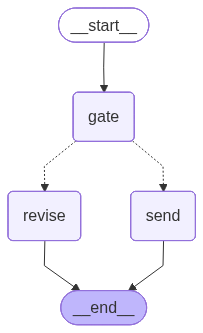

In [5]:
try:
    from IPython.display import Image, display

    png = g.get_graph().draw_mermaid_png()
    display(Image(png))
except Exception as exc:
    print("Mermaid PNG export skipped:", exc)
    print(g.get_graph().draw_mermaid())

In [1]:
import importlib.util
importlib.util.find_spec("mcp")

ModuleSpec(name='mcp', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000013C71C14AD0>, origin='d:\\Ambilio\\EXL-CampusHire\\Week2\\.venv\\Lib\\site-packages\\mcp\\__init__.py', submodule_search_locations=['d:\\Ambilio\\EXL-CampusHire\\Week2\\.venv\\Lib\\site-packages\\mcp'])

In [5]:
import json
from typing import Literal

from pydantic import BaseModel, Field


class ClaimLookupInput(BaseModel):
    """Arguments the agent must send to claim_lookup."""

    claim_id: str = Field(..., pattern=r"^CLM-\d{6}$")


tool_schema = {
    "name": "claim_lookup",
    "description": "Fetch claim routing metadata by claim id.",
    "parameters": ClaimLookupInput.model_json_schema(),
}
print(json.dumps(tool_schema, indent=2))

{
  "name": "claim_lookup",
  "description": "Fetch claim routing metadata by claim id.",
  "parameters": {
    "description": "Arguments the agent must send to claim_lookup.",
    "properties": {
      "claim_id": {
        "pattern": "^CLM-\\d{6}$",
        "title": "Claim Id",
        "type": "string"
      }
    },
    "required": [
      "claim_id"
    ],
    "title": "ClaimLookupInput",
    "type": "object"
  }
}


In [16]:
class TriageDecision(BaseModel):
    """Final structured decision returned by the operations assistant."""

    lane: Literal["insurance", "banking", "logistics"] = Field(
        description="Domain lane that produced the decision"
    )
    case_id: str = Field(
        default=None, description="Primary case identifier (claim id, loan id, or container id)"
    )

td = TriageDecision(lane="banking")
print(td)
td = TriageDecision(lane="banking", case_id="123")
print(td)

lane='banking' case_id=None
lane='banking' case_id='123'
